<a href="https://colab.research.google.com/github/ZhanRomanov/Bakalaurs/blob/main/Bakalaurs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



 Bibliotēku importēšana un vides sagatavošana

In [ ]:
#Vides sagatavošana, Google Drive pieslēgšana un bibliotēku importēšana

from google.colab import drive
drive.mount('/content/drive')

import os
import csv
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Fiksējam sēklas (seeds) eksperimentu atkārtojamībai
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Direktoriju un failu sagatavošana Google Drive
BASE_DIR = '/content/drive/MyDrive/Bakalaurs_Dati'

WEIGHTS_DIR = f"{BASE_DIR}/weights"
os.makedirs(WEIGHTS_DIR, exist_ok=True)

CONFIGS_FILE = f"{BASE_DIR}/configs.csv"
METADATA_FILE = f"{BASE_DIR}/models_metadata.csv"

# DROŠA FAILU IZVEIDE (Netīrīs jau esošos datus)
if not os.path.exists(CONFIGS_FILE):
    with open(CONFIGS_FILE, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['model_id', 'learning_rate', 'batch_size', 'optimizer', 'l2_reg', 'dropout', 'activation', 'epochs'])
        print("Izveidots jauns configs.csv fails.")
else:
    print("configs.csv jau eksistē. Dati tiks pievienoti klāt.")

if not os.path.exists(METADATA_FILE):
    with open(METADATA_FILE, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['model_id', 'test_accuracy', 'quality_class'])
        print("Izveidots jauns models_metadata.csv fails.")
else:
    print("models_metadata.csv jau eksistē. Dati tiks pievienoti klāt.")

print(f"Vide sagatavota! Strādājam direktorijā: {BASE_DIR}")

Mounted at /content/drive
configs.csv jau eksistē. Dati tiks pievienoti klāt.
models_metadata.csv jau eksistē. Dati tiks pievienoti klāt.
Vide sagatavota! Strādājam direktorijā: /content/drive/MyDrive/Bakalaurs_Dati


Hiperparametru ģenerēšana

In [ ]:
def generate_hyperparameters():
    """Ģenerē nejaušu hiperparametru konfigurāciju."""
    learning_rate = 10 ** random.choice([-5,-4,-3,-2, -1])
    batch_size = random.choice([16, 32, 64, 128, 256, 512])
    optimizer_choice = random.choice(['sgd', 'adam'])
    l2_reg = random.choice([0, 1e-5, 1e-4, 1e-3])
    dropout_prob = random.choice([0, 0.2, 0.5])
    activation_fn = random.choice(['relu', 'sigmoid'])
    epochs = random.choice([5, 10, 20, 35, 50])

    return {
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'optimizer': optimizer_choice,
        'l2_reg': l2_reg,
        'dropout': dropout_prob,
        'activation': activation_fn,
        'epochs': epochs
    }

print("Hiperparametru ģenerēšanas funkcija gatava!")

Hiperparametru ģenerēšanas funkcija gatava!


Modeļa arhitektūra un apmācības loģika

In [ ]:
class MLP_MNIST(nn.Module):
    def __init__(self, activation_fn_name, dropout_prob):
        super(MLP_MNIST, self).__init__()

        # Slāņu definīcijas
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

        # Aktivācijas funkcija
        if activation_fn_name == 'relu':
            self.activation = nn.ReLU()
        else:
            self.activation = nn.Sigmoid()

        # Dropout slānis
        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.fc3(x)
        return x

def train_model(model, train_loader, optimizer, criterion, epochs, device):
    model.train()
    for epoch in range(epochs):
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    return 100 * correct / total

print("Modeļa klase un apmācības/novērtēšanas funkcijas gatavas!")

Datu ģenerēšana un svaru saglabāšana

In [ ]:
# 4. šūna: Galvenais ģenerēšanas cikls ar atsākšanas (resume) funkciju

# Ierīces iestatīšana
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Izmanto ierīci: {device}")

# Datu transformācijas
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Pilnās MNIST datu kopas ielāde
print("Ielādē MNIST datus...")
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

NUM_MODELS = 500

# Pārbaudām pēdējo saglabāto modeli 'weights' mapē
last_model_id = 0
if os.path.exists(WEIGHTS_DIR):
    # Atrodam visus failus, kas beidzas ar .npy
    npy_files = [f for f in os.listdir(WEIGHTS_DIR) if f.startswith('model_') and f.endswith('.npy')]

    if npy_files:
        # Izvelkam numurus, piemēram, no "model_0043_layer1.npy" dabūjam 43
        model_numbers = [int(f.split('_')[1]) for f in npy_files]
        last_model_id = max(model_numbers)

print(f"\n--- 'weights' mapē atklāti {last_model_id} modeļi. Turpinām no {last_model_id + 1}. modeļa ---")

start_index = last_model_id # Pielāgojam indeksu ciklam

# Sēklu atiestatīšana un "pārtīšana"
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Tukšgaitā izsaucam ģenerēšanu iepriekšējiem modeļiem, lai
# random stāvoklis nonāktu tieši tur, kur tam jābūt!
for _ in range(start_index):
    _ = generate_hyperparameters()

# Galvenais ģenerēšanas cikls (sākas no start_index)
for i in range(start_index, NUM_MODELS):
    model_id = f"model_{i+1:04d}"
    params = generate_hyperparameters()

    print(f"[{i+1}/{NUM_MODELS}] Ģenerē {model_id} ar parametriem: {params}")

    # Datu lādētāji konkrētajam modelim
    train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=params['batch_size'], shuffle=False)

    # Modeļa iniciēšana
    model = MLP_MNIST(params['activation'], params['dropout']).to(device)

    # Zaudējuma funkcija
    criterion = nn.CrossEntropyLoss()

    # Optimizatora izvēle
    if params['optimizer'] == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=params['learning_rate'],
                              momentum=0.9, weight_decay=params['l2_reg'])
    else:
        optimizer = optim.Adam(model.parameters(), lr=params['learning_rate'],
                               weight_decay=params['l2_reg'])

    # Apmācība
    train_model(model, train_loader, optimizer, criterion, params['epochs'], device)

    # Novērtēšana
    test_acc = evaluate_model(model, test_loader, device)

    # Kvalitātes marķēšana
    if test_acc >= 95.0:
        quality_class = "labs"
    elif test_acc >= 80.0:
        quality_class = "vidējs"
    else:
        quality_class = "slikts"

    print(f"--> {model_id} pabeigts. Precizitāte: {test_acc:.2f}% | Klase: {quality_class}\n")

    # Svaru saglabāšana
    state_dict = model.state_dict()
    np.save(os.path.join(WEIGHTS_DIR, f"{model_id}_layer1.npy"), state_dict['fc1.weight'].cpu().numpy())
    np.save(os.path.join(WEIGHTS_DIR, f"{model_id}_layer2.npy"), state_dict['fc2.weight'].cpu().numpy())
    np.save(os.path.join(WEIGHTS_DIR, f"{model_id}_layer3.npy"), state_dict['fc3.weight'].cpu().numpy())

    # Konfigurācijas saglabāšana CSV
    with open(CONFIGS_FILE, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            model_id, params['learning_rate'], params['batch_size'],
            params['optimizer'], params['l2_reg'], params['dropout'],
            params['activation'], params['epochs']
        ])

    # Metadatu saglabāšana CSV
    with open(METADATA_FILE, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([model_id, test_acc, quality_class])

print("Visi modeļi veiksmīgi ģenerēti un saglabāti!")

Statistisko pazīmju izguves

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# Bāzes direktorijas
BASE_DIR = '/content/drive/MyDrive/Bakalaurs_Dati'
WEIGHTS_DIR = f"{BASE_DIR}/weights"
METADATA_FILE = f"{BASE_DIR}/models_metadata.csv"
FEATURES_FILE = f"{BASE_DIR}/extracted_features.csv"

print("Sāku pazīmju izguvi...")

# Ielādējam metadatus, lai dabūtu kvalitātes klasi katram modelim
df_meta = pd.read_csv(METADATA_FILE)
# Izveidojam vārdnīcu ātrai meklēšanai: {'model_0001': 'vidējs', ...}
quality_map = dict(zip(df_meta['model_id'], df_meta['quality_class']))

features_list = []

# Iterējam cauri visiem 500 modeļiem
for i in range(1, 501):
    model_id = f"model_{i:04d}"

    # Svaru failu ceļi
    path_l1 = os.path.join(WEIGHTS_DIR, f"{model_id}_layer1.npy")
    path_l2 = os.path.join(WEIGHTS_DIR, f"{model_id}_layer2.npy")
    path_l3 = os.path.join(WEIGHTS_DIR, f"{model_id}_layer3.npy")

    # Drošības pārbaude (lai izlaistu, ja kāda iemesla dēļ fails neeksistē)
    if not (os.path.exists(path_l1) and os.path.exists(path_l2) and os.path.exists(path_l3)):
        print(f"KĻŪDA: Trūkst failu modelim {model_id}!")
        continue

    # Ielādējam un uzreiz "saplacinām" (flatten) matricas 1D masīvā statistikai
    w1 = np.load(path_l1).flatten()
    w2 = np.load(path_l2).flatten()
    w3 = np.load(path_l3).flatten()

    # Izveidojam bāzes vārdnīcu šim modelim
    model_features = {'model_id': model_id}

    # Aprēķinām 6 pazīmes katram no 3 slāņiem
    for layer_idx, w in enumerate([w1, w2, w3], start=1):
        model_features[f'l{layer_idx}_mean'] = np.mean(w)
        model_features[f'l{layer_idx}_var'] = np.var(w)
        model_features[f'l{layer_idx}_skew'] = skew(w)
        model_features[f'l{layer_idx}_kurtosis'] = kurtosis(w)
        model_features[f'l{layer_idx}_l2_norm'] = np.linalg.norm(w)
        model_features[f'l{layer_idx}_max_amp'] = np.max(np.abs(w))

    # Pievienojam mērķa mainīgo (quality_class)
    model_features['quality_class'] = quality_map.get(model_id, 'nezināms')

    features_list.append(model_features)

# Konvertējam uz Pandas DataFrame un saglabājam
df_features = pd.DataFrame(features_list)
df_features.to_csv(FEATURES_FILE, index=False)

print(f"Pazīmju inženierija pabeigta! Dati saglabāti failā: {FEATURES_FILE}")
print(f"Iegūtas {df_features.shape[1] - 2} pazīmes {df_features.shape[0]} modeļiem.")

Diagnostikas klasifikatora realizācija

Ielādēju datus...
Apmācības kopa: 400 modeļi
Testa kopa: 100 modeļi

Sāku modeļa apmācību un hiperparametru optimizāciju (GridSearchCV)...
Labākie parametri: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

=== REZULTĀTI UZ TESTA KOPAS ===
Kopējā precizitāte (Accuracy): 86.00%

Klasifikācijas atskaite:
              precision    recall  f1-score   support

        labs       0.80      0.97      0.88        33
      slikts       0.94      0.92      0.93        36
      vidējs       0.84      0.68      0.75        31

    accuracy                           0.86       100
   macro avg       0.86      0.85      0.85       100
weighted avg       0.86      0.86      0.86       100



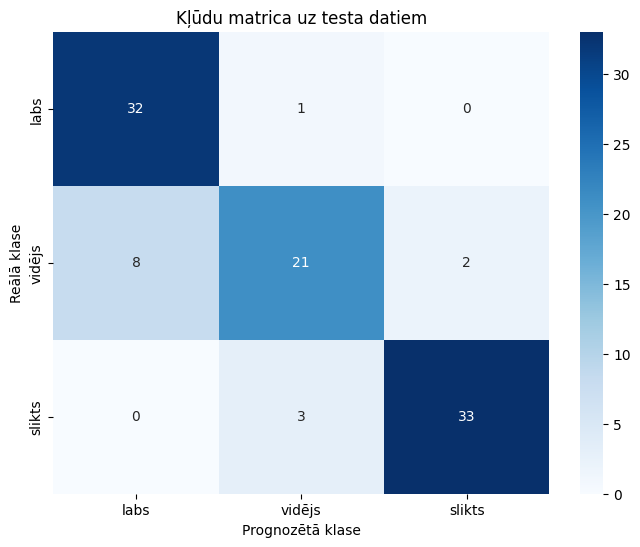

/tmp/ipykernel_3829/1450530003.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


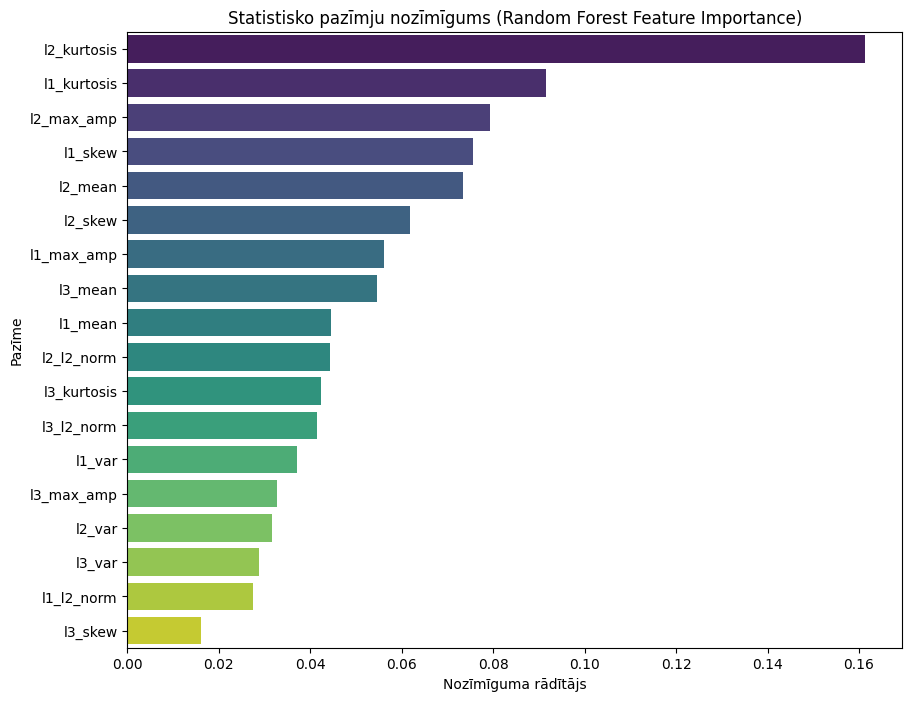

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Datu ielāde
BASE_DIR = '/content/drive/MyDrive/Bakalaurs_Dati'
FEATURES_FILE = f"{BASE_DIR}/extracted_features.csv"

print("Ielādēju datus...")
df = pd.read_csv(FEATURES_FILE)

# Atdalām pazīmes (X) no mērķa mainīgā (y)
# Izmetam 'model_id', jo tas nav statistisks rādītājs
X = df.drop(columns=['model_id', 'quality_class'])
y = df['quality_class']

# Datu sadale apmācības un testa kopās (80% / 20%)
# stratify=y nodrošina, ka klašu proporcijas abās kopās saglabājas vienādas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Apmācības kopa: {X_train.shape[0]} modeļi")
print(f"Testa kopa: {X_test.shape[0]} modeļi\n")

# Random Forest modeļa inicializācija un hiperparametru režģa meklēšana (Grid Search)
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],      # Koku skaits mežā
    'max_depth': [None, 10, 20, 30],     # Koku maksimālais dziļums
    'min_samples_split': [2, 5, 10]      # Minimālais paraugu skaits, lai sadalītu zaru
}

print("Sāku modeļa apmācību un hiperparametru optimizāciju (GridSearchCV)...")
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Labākie parametri: {grid_search.best_params_}\n")

# Modeļa novērtēšana uz testa datiem
y_pred = best_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"=== REZULTĀTI UZ TESTA KOPAS ===")
print(f"Kopējā precizitāte (Accuracy): {accuracy * 100:.2f}%\n")
print("Klasifikācijas atskaite:")
print(classification_report(y_test, y_pred))

# Vizualizācija: Kļūdu matrica (Confusion Matrix)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=['labs', 'vidējs', 'slikts'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['labs', 'vidējs', 'slikts'],
            yticklabels=['labs', 'vidējs', 'slikts'])
plt.title("Kļūdu matrica uz testa datiem")
plt.xlabel("Prognozētā klase")
plt.ylabel("Reālā klase")
plt.show()

# Vizualizācija: Pazīmju nozīmīgums (Feature Importance)
importances = best_rf.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title("Statistisko pazīmju nozīmīgums (Random Forest Feature Importance)")
plt.xlabel("Nozīmīguma rādītājs")
plt.ylabel("Pazīme")
plt.show()

Fashion-MNIST ģenerēšana

In [ ]:

import glob
import re
import os
import csv
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pandas as pd



def generate_hyperparameters():
    """Ģenerē nejaušu hiperparametru konfigurāciju."""
    learning_rate = 10 ** random.choice([-5, -4, -3, -2, -1])
    batch_size = random.choice([16, 32, 64, 128, 256, 512])
    optimizer_choice = random.choice(['sgd', 'adam'])
    l2_reg = random.choice([0, 1e-5, 1e-4, 1e-3])
    dropout_prob = random.choice([0, 0.2, 0.5])
    activation_fn = random.choice(['relu', 'sigmoid'])
    epochs = random.choice([5, 10, 20, 35, 50])

    return {
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'optimizer': optimizer_choice,
        'l2_reg': l2_reg,
        'dropout': dropout_prob,
        'activation': activation_fn,
        'epochs': epochs
    }

print("Hiperparametru ģenerēšanas funkcija gatava!")

# FASHION-MNIST EKSPERIMENTS: 200 modeļu ģenerēšana

# Ierīces iestatīšana
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Izmanto ierīci: {device}")

# Datu transformācijas
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Fashion-MNIST datu kopas ielāde
print("Ielādē Fashion-MNIST datus...")
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Direktorijas un faili Fashion eksperimentam
FASHION_WEIGHTS_DIR = "/content/drive/MyDrive/Bakalaurs_Dati/fashion_weights"
FASHION_CONFIGS_FILE = "/content/drive/MyDrive/Bakalaurs_Dati/fashion_configs.csv"
FASHION_METADATA_FILE = "/content/drive/MyDrive/Bakalaurs_Dati/fashion_models_metadata.csv"

os.makedirs(FASHION_WEIGHTS_DIR, exist_ok=True)

# Inicializējam CSV failus tikai tad, ja tie neeksistē
if not os.path.exists(FASHION_CONFIGS_FILE):
    with open(FASHION_CONFIGS_FILE, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['model_id', 'learning_rate', 'batch_size', 'optimizer', 'l2_reg', 'dropout', 'activation', 'epochs'])

if not os.path.exists(FASHION_METADATA_FILE):
    with open(FASHION_METADATA_FILE, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['model_id', 'test_accuracy', 'quality_class'])

# Modeļa definīcija (plašāka arhitektūra)

class MLP_Fashion(nn.Module):
    def __init__(self, activation_fn_name, dropout_prob):
        super(MLP_Fashion, self).__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

        if activation_fn_name == 'relu':
            self.activation = nn.ReLU()
        else:
            self.activation = nn.Sigmoid()

        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.fc3(x)
        return x

# Apmācības un novērtēšanas funkcijas

def train_model(model, train_loader, optimizer, criterion, epochs, device):
    model.train()
    for epoch in range(epochs):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    return 100 * correct / total


last_model_id = 0
if os.path.exists(FASHION_CONFIGS_FILE):
    df = pd.read_csv(FASHION_CONFIGS_FILE)
    if not df.empty:
        # Izvelkam numurus no 'model_id' kolonnas (formāts: f_model_XXXX)
        ids = df['model_id'].str.replace('f_model_', '').astype(int)
        last_model_id = ids.max()

print(f"\n--- 'fashion_configs.csv' atklāti {last_model_id} modeļi. Turpinām no {last_model_id + 1}. modeļa ---")


# Sēklu atiestatīšana un "pārtīšana"

torch.manual_seed(123)
np.random.seed(123)
random.seed(123)

# Pārtinam ģeneratoru, lai nākamie hiperparametri atbilstu secībai
for _ in range(last_model_id):
    generate_hyperparameters()


# Galvenais ģenerēšanas cikls (sākas no last_model_id, līdz 200)

NUM_MODELS = 200

for i in range(last_model_id, NUM_MODELS):
    model_id = f"f_model_{i+1:04d}"
    params = generate_hyperparameters()

    print(f"[{i+1}/{NUM_MODELS}] Ģenerē {model_id} ar parametriem: {params}")

    train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=params['batch_size'], shuffle=False)

    model = MLP_Fashion(params['activation'], params['dropout']).to(device)
    criterion = nn.CrossEntropyLoss()

    if params['optimizer'] == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=params['learning_rate'],
                              momentum=0.9, weight_decay=params['l2_reg'])
    else:
        optimizer = optim.Adam(model.parameters(), lr=params['learning_rate'],
                               weight_decay=params['l2_reg'])

    train_model(model, train_loader, optimizer, criterion, params['epochs'], device)
    test_acc = evaluate_model(model, test_loader, device)

    if test_acc >= 95.0:
        quality_class = "labs"
    elif test_acc >= 80.0:
        quality_class = "vidējs"
    else:
        quality_class = "slikts"

    print(f"--> {model_id} pabeigts. Precizitāte: {test_acc:.2f}% | Klase: {quality_class}\n")

    # Svaru saglabāšana
    np.save(os.path.join(FASHION_WEIGHTS_DIR, f"{model_id}_layer1.npy"), model.fc1.weight.data.cpu().numpy())
    np.save(os.path.join(FASHION_WEIGHTS_DIR, f"{model_id}_layer2.npy"), model.fc2.weight.data.cpu().numpy())
    np.save(os.path.join(FASHION_WEIGHTS_DIR, f"{model_id}_layer3.npy"), model.fc3.weight.data.cpu().numpy())

    # Konfigurācijas saglabāšana CSV
    with open(FASHION_CONFIGS_FILE, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            model_id, params['learning_rate'], params['batch_size'],
            params['optimizer'], params['l2_reg'], params['dropout'],
            params['activation'], params['epochs']
        ])

    # Metadatu saglabāšana CSV
    with open(FASHION_METADATA_FILE, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([model_id, test_acc, quality_class])

print("Visi 200 Fashion-MNIST modeļi veiksmīgi ģenerēti un saglabāti!")

Hiperparametru ģenerēšanas funkcija gatava!
Izmanto ierīci: cpu
Ielādē Fashion-MNIST datus...


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.47MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.7MB/s]



--- 'fashion_configs.csv' atklāti 200 modeļi. Turpinām no 201. modeļa ---
Visi 200 Fashion-MNIST modeļi veiksmīgi ģenerēti un saglabāti!


Statistisko pazīmju izguves(FashionMNIST)

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# Bāzes direktorijas
BASE_DIR = '/content/drive/MyDrive/Bakalaurs_Dati'
WEIGHTS_DIR = f"{BASE_DIR}/fashion_weights"           # Fashion modeļu svaru mape
METADATA_FILE = f"{BASE_DIR}/fashion_models_metadata.csv"  # Fashion metadati
FEATURES_FILE = f"{BASE_DIR}/fashion_extracted_features.csv"  # Izvades fails

print("Sāku pazīmju izguvi Fashion-MNIST modeļiem...")

# Ielādējam metadatus, lai dabūtu kvalitātes klasi katram modelim
df_meta = pd.read_csv(METADATA_FILE)
# Izveidojam vārdnīcu ātrai meklēšanai: {'f_model_0001': 'vidējs', ...}
quality_map = dict(zip(df_meta['model_id'], df_meta['quality_class']))

features_list = []

# Iterējam cauri visiem 200 modeļiem (ID no 1 līdz 200)
for i in range(1, 201):
    model_id = f"f_model_{i:04d}"   # Piemēram, f_model_0001

    # Svaru failu ceļi
    path_l1 = os.path.join(WEIGHTS_DIR, f"{model_id}_layer1.npy")
    path_l2 = os.path.join(WEIGHTS_DIR, f"{model_id}_layer2.npy")
    path_l3 = os.path.join(WEIGHTS_DIR, f"{model_id}_layer3.npy")

    # Drošības pārbaude (lai izlaistu, ja kāda iemesla dēļ fails neeksistē)
    if not (os.path.exists(path_l1) and os.path.exists(path_l2) and os.path.exists(path_l3)):
        print(f"KĻŪDA: Trūkst failu modelim {model_id}!")
        continue

    # Ielādējam un saplacinām matricas
    w1 = np.load(path_l1).flatten()
    w2 = np.load(path_l2).flatten()
    w3 = np.load(path_l3).flatten()

    # Izveidojam bāzes vārdnīcu šim modelim
    model_features = {'model_id': model_id}

    # Aprēķinām 6 pazīmes katram no 3 slāņiem
    for layer_idx, w in enumerate([w1, w2, w3], start=1):
        model_features[f'l{layer_idx}_mean'] = np.mean(w)
        model_features[f'l{layer_idx}_var'] = np.var(w)
        model_features[f'l{layer_idx}_skew'] = skew(w)
        model_features[f'l{layer_idx}_kurtosis'] = kurtosis(w)
        model_features[f'l{layer_idx}_l2_norm'] = np.linalg.norm(w)
        model_features[f'l{layer_idx}_max_amp'] = np.max(np.abs(w))

    # Pievienojam mērķa mainīgo (quality_class)
    model_features['quality_class'] = quality_map.get(model_id, 'nezināms')

    features_list.append(model_features)

# Konvertējam uz Pandas DataFrame un saglabājam
df_features = pd.DataFrame(features_list)
df_features.to_csv(FEATURES_FILE, index=False)

print(f"Pazīmju inženierija pabeigta! Dati saglabāti failā: {FEATURES_FILE}")
print(f"Iegūtas {df_features.shape[1] - 2} pazīmes no {df_features.shape[0]} modeļiem.")

Sāku pazīmju izguvi Fashion-MNIST modeļiem...
Pazīmju inženierija pabeigta! Dati saglabāti failā: /content/drive/MyDrive/Bakalaurs_Dati/fashion_extracted_features.csv
Iegūtas 18 pazīmes no 200 modeļiem.


Eksperiments ar FASHION-MNIST

=== Sāku vispārināšanas (Zero-Shot) pārbaudi ar esošo Random Forest ===
Testēšanai sagatavoti 200 modeļi.

 ZERO-SHOT PRECIZITĀTE UZ FASHION-MNIST: 56.50%

Klasifikācijas atskaite:
              precision    recall  f1-score   support

        labs       0.00      0.00      0.00         0
      slikts       0.92      0.89      0.90        87
      vidējs       0.82      0.32      0.46       113

    accuracy                           0.56       200
   macro avg       0.58      0.40      0.45       200
weighted avg       0.86      0.56      0.65       200



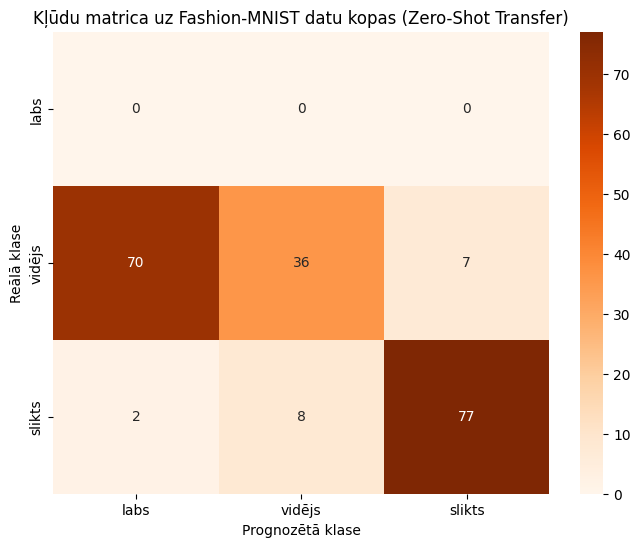

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=== Sāku vispārināšanas (Zero-Shot) pārbaudi ar esošo Random Forest ===")

# Ceļš uz Fashion-MNIST pazīmju failu
FASHION_FEATURES_FILE = '/content/drive/MyDrive/Bakalaurs_Dati/fashion_extracted_features.csv'

# Ielādējam Fashion-MNIST pazīmes
df_fashion = pd.read_csv(FASHION_FEATURES_FILE)

# Drošības solis: izmetam jebkuras rindas ar tukšumiem, ja tādi tomēr palikuši
df_fashion = df_fashion.dropna()

print(f"Testēšanai sagatavoti {len(df_fashion)} modeļi.")

# Atdalām pazīmes (X) un mērķa mainīgo (y)
X_fashion = df_fashion.drop(columns=['model_id', 'quality_class'])
y_fashion = df_fashion['quality_class']

# best_rf.feature_names_in_ satur pareizo secību no MNIST fāzes
X_fashion = X_fashion[best_rf.feature_names_in_]

# VEICAM PROGNOZI AR VECO MODELI (Izmantojam tikai predict()!)
y_pred_fashion = best_rf.predict(X_fashion)

# Rezultātu izvadīšana
accuracy_fashion = accuracy_score(y_fashion, y_pred_fashion)
print(f"\n=======================================================")
print(f" ZERO-SHOT PRECIZITĀTE UZ FASHION-MNIST: {accuracy_fashion * 100:.2f}%")
print(f"=======================================================\n")

print("Klasifikācijas atskaite:")
print(classification_report(y_fashion, y_pred_fashion, zero_division=0))

# Kļūdu matricas vizualizācija (Oranžā tēmā, lai atšķiras no pirmās)
plt.figure(figsize=(8, 6))
cm_fashion = confusion_matrix(y_fashion, y_pred_fashion, labels=['labs', 'vidējs', 'slikts'])
sns.heatmap(cm_fashion, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['labs', 'vidējs', 'slikts'],
            yticklabels=['labs', 'vidējs', 'slikts'])
plt.title("Kļūdu matrica uz Fashion-MNIST datu kopas (Zero-Shot Transfer)")
plt.xlabel("Prognozētā klase")
plt.ylabel("Reālā klase")
plt.show()

Fashion-MNIST modeļu bāzes precizitātes sadalījums

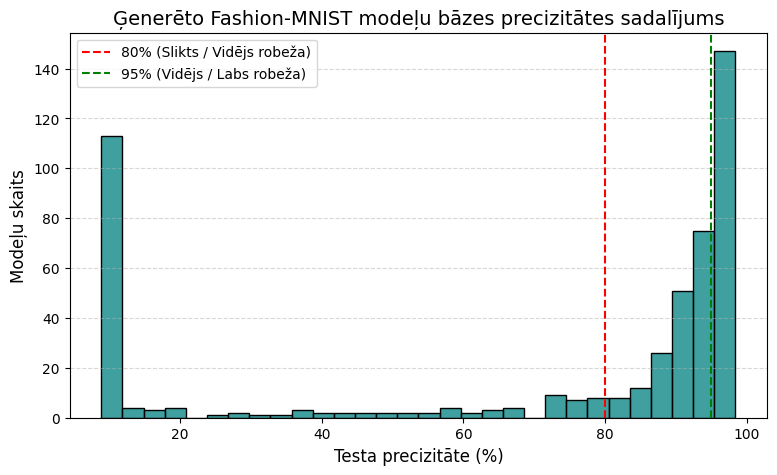

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ielādējam metadatu failu (kur ir 'test_accuracy')
META_FILE = '/content/drive/MyDrive/Bakalaurs_Dati/models_metadata.csv'
df_meta = pd.read_csv(META_FILE)

plt.figure(figsize=(9, 5))
sns.histplot(data=df_meta, x='test_accuracy', bins=30, kde=False, color='teal')

# Pievienojam vertikālas līnijas, kas norāda tavas klases robežas
plt.axvline(80, color='red', linestyle='--', label='80% (Slikts / Vidējs robeža)')
plt.axvline(95, color='green', linestyle='--', label='95% (Vidējs / Labs robeža)')

plt.title("Ģenerēto Fashion-MNIST modeļu bāzes precizitātes sadalījums", fontsize=14)
plt.xlabel("Testa precizitāte (%)", fontsize=12)
plt.ylabel("Modeļu skaits", fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Hiperparametru sadalījums

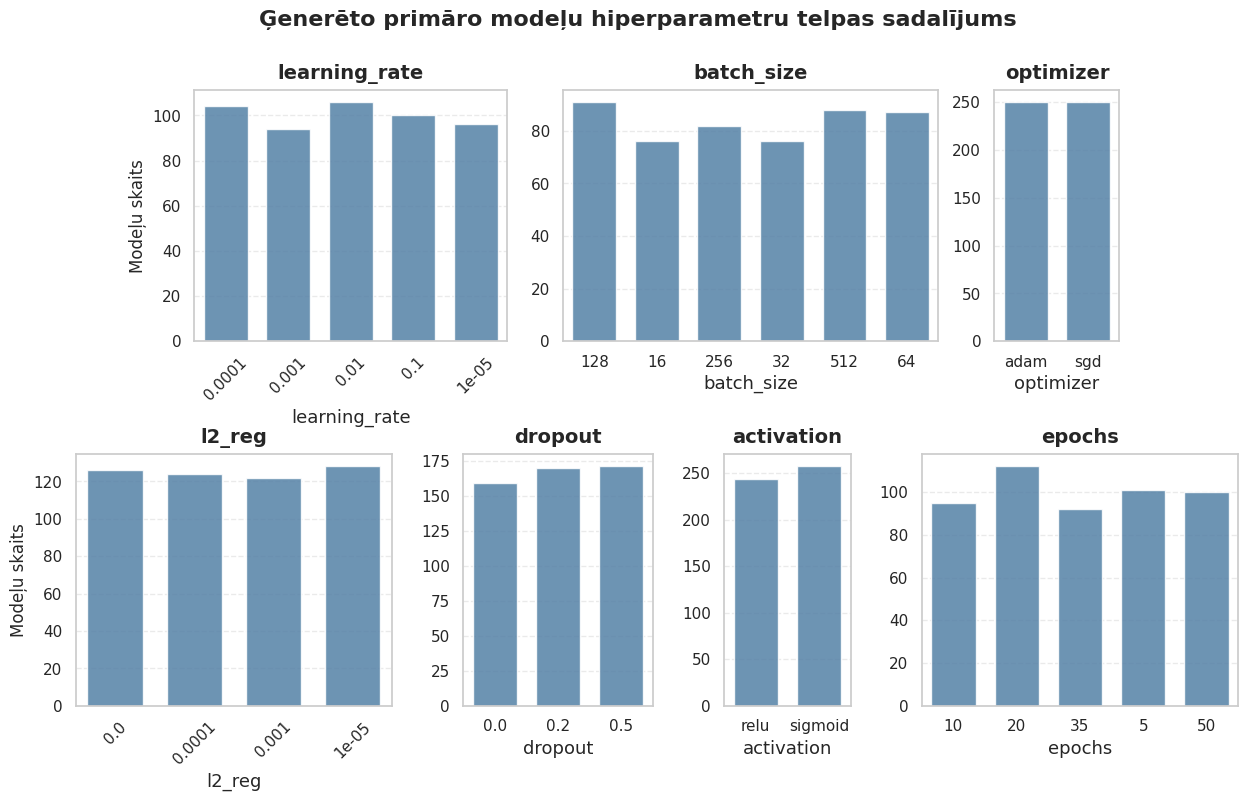

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Ielādējam datus
CONFIGS_FILE = '/content/drive/MyDrive/Bakalaurs_Dati/configs.csv'
df_configs = pd.read_csv(CONFIGS_FILE)

row1_params = ['learning_rate', 'batch_size', 'optimizer']
row2_params = ['l2_reg', 'dropout', 'activation', 'epochs']

# Stabiņu proporcijas (vienādiem rāmju platumiem)
r1_widths = [5, 6, 2]
r2_widths = [5, 3, 2, 5]

total_r1 = sum(r1_widths)
total_r2 = sum(r2_widths)
max_w = max(total_r1, total_r2)

# Liels rāmis (15x8)
fig = plt.figure(figsize=(15, 8))
gs_master = gridspec.GridSpec(2, 1, height_ratios=[1, 1], hspace=0.45)

spacer1 = (max_w - total_r1) / 2
gs_top = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=gs_master[0],
                                          width_ratios=[spacer1, 5, 6, 2, spacer1], wspace=0.3)

gs_bottom = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs_master[1],
                                             width_ratios=r2_widths, wspace=0.3)

axes_r1 = [fig.add_subplot(gs_top[1]), fig.add_subplot(gs_top[2]), fig.add_subplot(gs_top[3])]
axes_r2 = [fig.add_subplot(gs_bottom[i]) for i in range(4)]

all_axes = axes_r1 + axes_r2
all_params = row1_params + row2_params
base_color = "steelblue"

for i, param in enumerate(all_params):
    df_configs[param] = df_configs[param].astype(str)
    unique_vals = sorted(df_configs[param].unique())
    sns.countplot(data=df_configs, x=param, ax=all_axes[i], color=base_color,
                  alpha=0.85, order=unique_vals, width=0.7)

    all_axes[i].set_title(f"{param}", fontsize=14, fontweight='bold', pad=8)
    all_axes[i].set_xlabel(f"{param}", fontsize=13)

    all_axes[i].set_ylabel("Modeļu skaits" if i in [0, 3] else "", fontsize=12)

    all_axes[i].tick_params(axis='x', labelsize=11, rotation=45 if param in ['learning_rate', 'l2_reg'] else 0)
    all_axes[i].tick_params(axis='y', labelsize=11)
    all_axes[i].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle("Ģenerēto primāro modeļu hiperparametru telpas sadalījums", fontsize=16, fontweight='bold', y=0.98)

plt.show()

Tabula

In [ ]:
# Izvadām precīzus skaitļus konsolē tavam Word dokumentam (4.2. tabulai)
print("\n=== PRECIZI SKAITĻI 4.2. TABULAI ===")
for index, row in feature_df.iterrows():
    if row['Importance'] > 0.01: # Rāda tikai nozīmīgās
        print(f"{row['Feature']:<15} | {row['Importance']:.4f}")


=== PRECIZI SKAITĻI 4.2. TABULAI ===
l2_kurtosis     | 0.1614
l1_kurtosis     | 0.0916
l2_max_amp      | 0.0793
l1_skew         | 0.0756
l2_mean         | 0.0734
l2_skew         | 0.0618
l1_max_amp      | 0.0561
l3_mean         | 0.0546
l1_mean         | 0.0444
l2_l2_norm      | 0.0444
l3_kurtosis     | 0.0424
l3_l2_norm      | 0.0414
l1_var          | 0.0370
l3_max_amp      | 0.0327
l2_var          | 0.0315
l3_var          | 0.0287
l1_l2_norm      | 0.0274
l3_skew         | 0.0162
